In [56]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [57]:
parquet_path = Path("../outputs/epochs.parquet")

# ==========================================================
# 1. Cargar parquet
# ==========================================================
df = pd.read_parquet(parquet_path)
df = df.sort_values(["subject"]).reset_index(drop=True)

In [58]:
def plot_epochs_multichannel(
    df,
    tmin=0.0,
    tmax=0.8,
    epoch_idx=0,
    channels=None
):
    """
    Plotea todos los canales de epochs para las clases 0 y 1 al estilo EEG.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas ['subject', 'epoch', 'label', 'data'].
    tmin : float
        Tiempo inicial en segundos.
    tmax : float
        Tiempo final en segundos.
    epoch_idx : int
        Índice del epoch a seleccionar por clase. Por defecto 0 (primer epoch).
    channels : list[int] or None
        Lista de canales a plotear. Si None, todos los canales.
    """

    df = df.sort_values(["subject", "epoch"]).reset_index(drop=True)

    # Seleccionar un epoch por clase
    row_l0 = df[df["label"] == 0].iloc[epoch_idx]
    row_l1 = df[df["label"] == 1].iloc[epoch_idx]

    rows = [row_l0, row_l1]
    titles = ["Epoch label = 0 (non-target)", "Epoch label = 1 (target)"]

    def plot_multichannel_epoch(ax, epoch_data, times, title):
        n_channels, n_times = epoch_data.shape

        # Si se seleccionan canales específicos
        if channels is not None:
            epoch_data = epoch_data[channels]
            n_channels = len(channels)

        # Offset robusto (percentil 95)
        scale = np.percentile(np.abs(epoch_data), 95)
        offset = scale * 3.5   # separador vertical claro

        offsets = np.arange(n_channels)[::-1] * offset

        for ch in range(n_channels):
            ax.plot(
                times,
                epoch_data[ch] + offsets[ch],
                linewidth=0.9
            )

        ax.set_yticks(offsets)
        if channels is None:
            ax.set_yticklabels([f"Ch {i}" for i in range(n_channels)][::-1])
        else:
            ax.set_yticklabels([f"Ch {ch}" for ch in channels][::-1])

        ax.set_title(title, fontsize=11)
        ax.set_xlim(times[0], times[-1])

        ax.grid(True, axis="x", alpha=0.3)
        ax.grid(False, axis="y")

    # ==========================================================
    # Plot
    # ==========================================================
    fig, axes = plt.subplots(
        2, 1,
        figsize=(14, 10),
        sharex=True
    )

    for ax, row, title in zip(axes, rows, titles):
        data = row["data"]
        if isinstance(data, str):
            data = ast.literal_eval(data)

        epoch_data = np.stack(data, axis=0).astype(np.float32)
        times = np.linspace(tmin, tmax, epoch_data.shape[1])

        plot_multichannel_epoch(ax, epoch_data, times, title)

    axes[-1].set_xlabel("Tiempo (s)", fontsize=11)

    plt.suptitle(
        "EEG multicanal – comparación non-target vs target",
        fontsize=14,
        y=0.97
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def plot_epochs(df, channel=None, epoch_idx=0):
    """
    Plotea epochs para las clases 0 y 1.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas ['subject', 'epoch', 'label', 'data'].
    channel : int or None
        Canal a plotear. Si None, promedia sobre los canales.
    epoch_idx : int
        Índice del epoch a seleccionar por clase. Por defecto 0 (primer epoch).
    """
    df = df.sort_values(["subject", "epoch"]).reset_index(drop=True)

    # Seleccionar un epoch por clase
    row_l0 = df[df["label"] == 0].iloc[epoch_idx]
    row_l1 = df[df["label"] == 1].iloc[epoch_idx]

    rows = [row_l0, row_l1]
    titles = ["Epoch label = 0 (non-target)", "Epoch label = 1 (target)"]

    # ==========================================================
    # Plot
    # ==========================================================
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

    for ax, row, title in zip(axes, rows, titles):
        data = row["data"]
        if isinstance(data, str):
            data = ast.literal_eval(data)

        # (n_channels, n_times)
        epoch_data = np.stack(data, axis=0).astype(np.float32)

        # Promedio sobre canales si channel es None, sino usar canal especificado
        if channel is None:
            epoch_mean = epoch_data.mean(axis=0)
        else:
            epoch_mean = epoch_data[channel]

        ax.plot(epoch_mean, linewidth=1.2)
        ax.set_title(title)
        ax.grid(True)

    axes[-1].set_xlabel("Muestras")
    fig.suptitle("Comparación de epochs: non-target vs target", y=0.98)
    plt.tight_layout()
    plt.show()

## Todos los canales

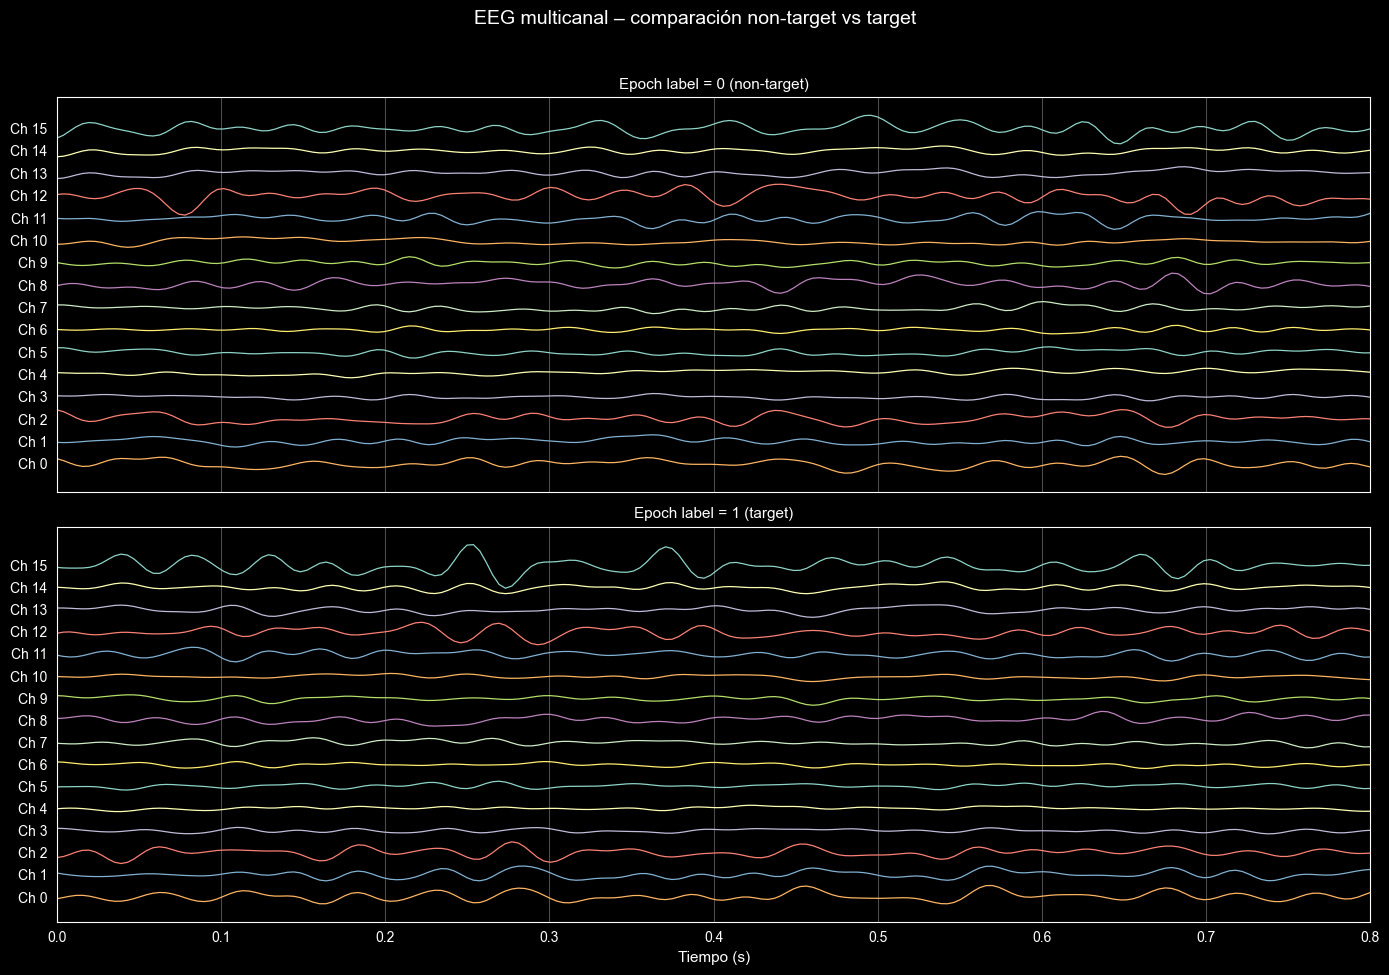

In [59]:
plot_epochs_multichannel(df)

## Topo-plot

## Promedio de canales

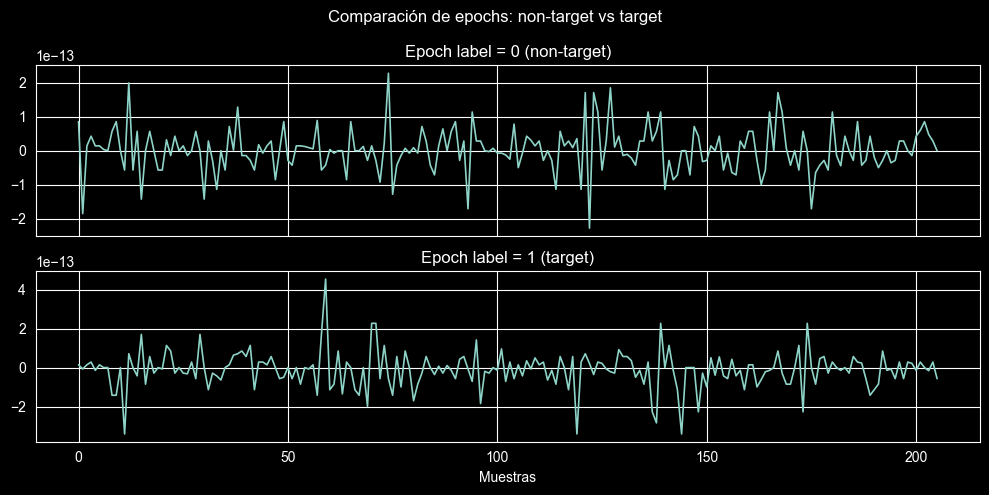

In [60]:
plot_epochs(df)

## Canal 4

Canal que no parece mostrar una fuerte relacion con la variable objetivo

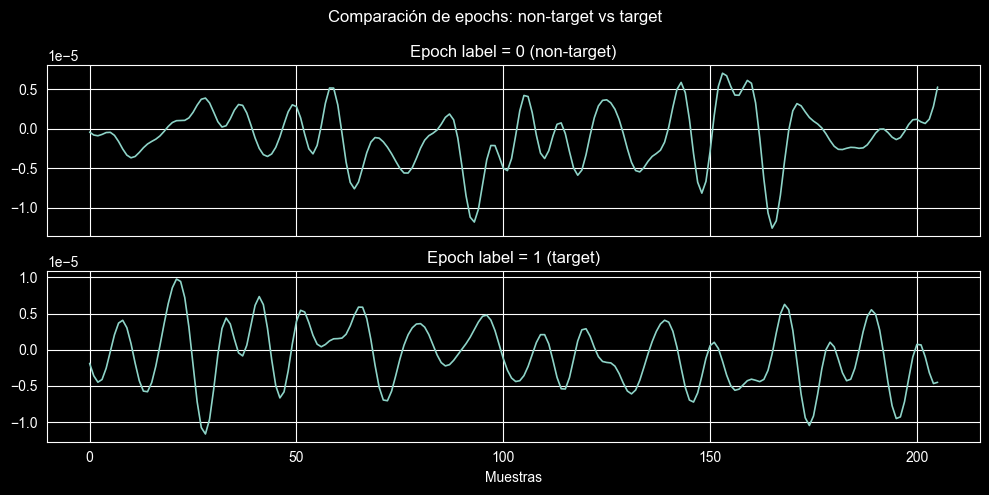

In [61]:
plot_epochs(df, channel=4)

## Canal 16

Canal que parece mostrar una fuerte relacion con la variable objetivo en múltiples features

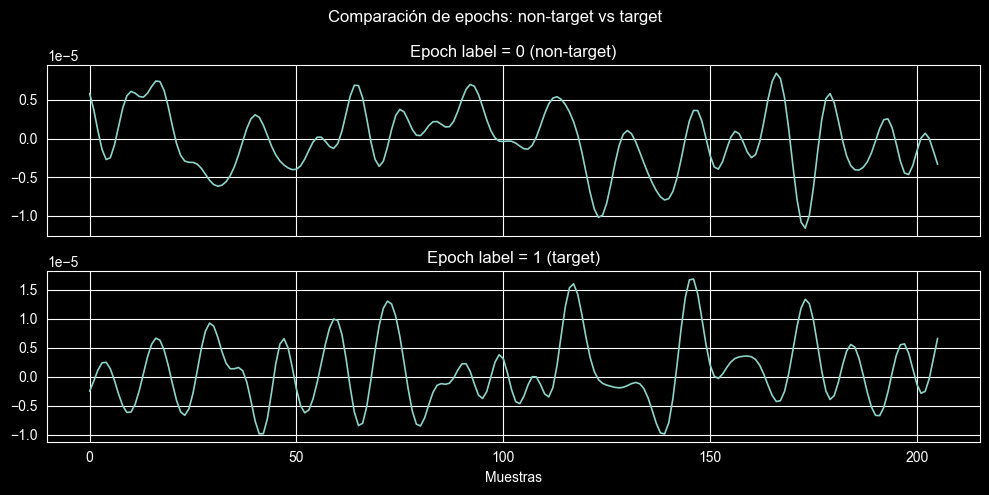

In [63]:
plot_epochs(df, channel=15)

## Todos los canales

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

# ==========================================================
# CONFIG
# ==========================================================
parquet_path = Path("../outputs/epochs.parquet")
tmin = 0.0
tmax = 0.8

# ==========================================================
# 1. Cargar parquet
# ==========================================================
df = pd.read_parquet(parquet_path)
df = df.sort_values(["subject", "epoch"]).reset_index(drop=True)

row_l0 = df[df["label"] == 0].iloc[0]
row_l1 = df[df["label"] == 1].iloc[0]

rows = [row_l0, row_l1]
titles = ["Epoch label = 0 (non-target)", "Epoch label = 1 (target)"]

# ==========================================================
# 2. Función de plot multicanal (EEG-style)
# ==========================================================
def plot_multichannel_epoch(ax, epoch_data, times, title):

    n_channels, n_times = epoch_data.shape

    # Offset robusto (percentil 95)
    scale = np.percentile(np.abs(epoch_data), 95)
    offset = scale * 3.5   # separador vertical claro

    offsets = np.arange(n_channels)[::-1] * offset

    for ch in range(n_channels):
        ax.plot(
            times,
            epoch_data[ch] + offsets[ch],
            linewidth=0.9
        )

    ax.set_yticks(offsets)
    ax.set_yticklabels([f"Ch {i}" for i in range(n_channels)][::-1])
    ax.set_title(title, fontsize=11)
    ax.set_xlim(times[0], times[-1])

    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(False, axis="y")

# ==========================================================
# 3. Plot
# ==========================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10),
    sharex=True
)

for ax, row, title in zip(axes, rows, titles):

    data = row["data"]
    if isinstance(data, str):
        data = ast.literal_eval(data)

    epoch_data = np.stack(data, axis=0).astype(np.float32)

    times = np.linspace(tmin, tmax, epoch_data.shape[1])

    plot_multichannel_epoch(ax, epoch_data, times, title)

axes[-1].set_xlabel("Tiempo (s)", fontsize=11)

plt.suptitle(
    "EEG multicanal – comparación non-target vs target",
    fontsize=14,
    y=0.97
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Escoge un sujeto cualquiera
subject_id = 0
epochs_subject = epochs[epochs.metadata['subject'] == subject_id]

# Canales de interés para P300
channels = ["EEG_Pz", "EEG_Cz", "EEG_CPz"]

# Graficar target vs non-target
target_epochs = epochs_subject['target']
nontarget_epochs = epochs_subject['non_target']

plt.figure(figsize=(12, 6))
for ch in channels:
    # Target
    t_data = target_epochs.get_data(picks=ch).mean(axis=0)
    plt.plot(target_epochs.times, t_data, label=f'{ch} target', linestyle='-')
    # Non-target
    nt_data = nontarget_epochs.get_data(picks=ch).mean(axis=0)
    plt.plot(target_epochs.times, nt_data, label=f'{ch} non-target', linestyle='--')

plt.axvline(0, color='k', linestyle=':')  # Stimulus onset
plt.title("Average target vs non-target")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.legend()
plt.show()
